# 04 · Evaluación final en DS2

**DS2 se evaluó una sola vez**, con los modelos ya congelados. Nada se ajustó después de ver
estos resultados: lo que cambie a partir de acá va a una versión 2 que habrá que validar de nuevo.

**Lo que estaba decidido de antemano** (`reports/model_selection.json`, escrito en la Fase 4):

- **Modelo primario:** baseline XGBoost (mayor F1 macro en validación cruzada dentro de DS1).
- **Modelo de comparación:** CNN 1D.
- **Riesgos a verificar**, anotados en las fases 1 a 4:
  1. Bloqueo de rama izquierda (registros **111** y **214**): en DS1 el baseline falló con el 207.
  2. Registro **232**, bradicárdico, que aporta el 75 % de los S de DS2: el modelo primario usa
     RR absolutos, que cambian entre pacientes.
  3. Clase **F**: casi toda está en el registro **213**, y en validación no se detectaba nunca.
  4. **V clasificados como N** (RISK-01), el error más grave.
  5. Registro **105**, el más ruidoso.

Este notebook solo *muestra* los resultados que produce `python -m ecg.evaluate_ds2`.

> Proyecto educativo y de investigación. No es un dispositivo médico.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ecg import config
from ecg.evaluate import confusion, per_class_metrics, per_record_metrics, summary
from ecg.evaluate_ds2 import predict_all, rhythm_labels
from ecg.segment import load_split

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
FIG_DIR = config.REPORTS_DIR / "figures"
pd.set_option("display.precision", 3)

ds2 = load_split("ds2")
y, records, symbols = ds2["y"], ds2["record"], ds2["symbol"]
preds = predict_all(ds2)          # modelos entrenados solo con DS1
selection = json.loads((config.REPORTS_DIR / "model_selection.json").read_text())
NAMES = {"baseline_xgb": "Baseline XGBoost (primario)", "cnn": "CNN 1D (comparación)"}
print(f"DS2: {len(y)} latidos de {len(np.unique(records))} pacientes nunca vistos")
selection

DS2: 49661 latidos de 22 pacientes nunca vistos


{'rule': 'Mayor F1 macro out-of-fold en DS1 (5 folds por paciente). Fijada antes de ver DS2.',
 'primary_model': 'baseline_xgb',
 'comparison_model': 'cnn',
 'cv_macro_f1': {'baseline_xgb': 0.4931,
  'cnn_mean_3_seeds': 0.4634,
  'cnn_sd': 0.0271},
 'cnn_config': {'rr': 'ratios', 'balance': 'weights', 'augment': True},
 'note': 'Ambos modelos se evalúan una sola vez en DS2; el primario se declara acá.'}

## 1. Resultado principal

In [2]:
tabla = pd.concat({NAMES[k]: per_class_metrics(y, p) for k, p in preds.items()}, names=["modelo"])
resumen = pd.DataFrame({NAMES[k]: summary(y, p) for k, p in preds.items()}).T[["macro_f1", "accuracy"]]
resumen["accuracy prediciendo siempre N"] = (y == "N").mean()
display(tabla.round(3))
resumen.round(3)

Se     +P     F1     TP     FN    FP  \
modelo                      clase                                            
Baseline XGBoost (primario) N      0.905  0.962  0.933  40039   4179  1594   
                            S      0.155  0.221  0.182    284   1552  1002   
                            V      0.964  0.852  0.905   3103    116   537   
                            F      0.137  0.017  0.030     53    335  3049   
CNN 1D (comparación)        N      0.697  0.973  0.813  30835  13383   847   
                            S      0.558  0.619  0.587   1024    812   631   
                            V      0.962  0.413  0.578   3096    123  4394   
                            F      0.008  0.000  0.001      3    385  8831   

                                       n  
modelo                      clase         
Baseline XGBoost (primario) N      44218  
                            S       1836  
                            V       3219  
                            F        388  
CNN 1D (comparación)        N      44218  
                            S       1836  
                            V       3219  
                            F        388

,macro_f1,accuracy,accuracy prediciendo siempre N
Baseline XGBoost (primario),0.512,0.876,0.89
CNN 1D (comparación),0.495,0.704,0.89


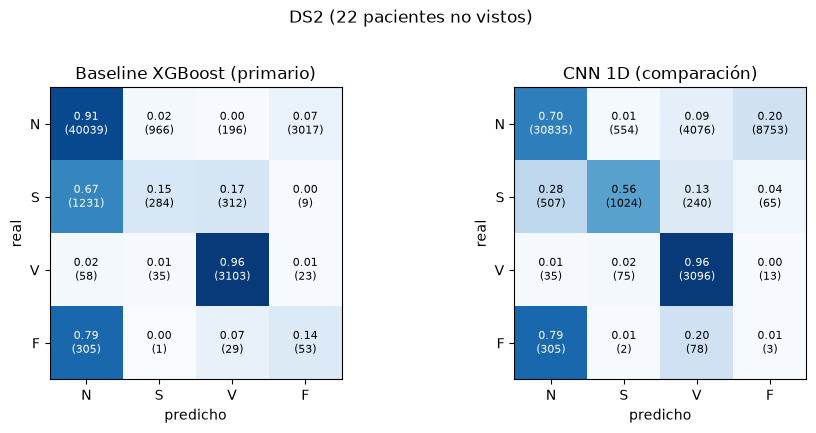

In [3]:
from IPython.display import Image
Image(str(FIG_DIR / "ds2_confusion.png"))

**Conclusiones:**

- **El modelo primario (baseline) obtiene F1 macro 0.512 en DS2**, apenas por encima del 0.493 que
  había dado la validación cruzada. La CNN queda en 0.49, también parecido a su 0.463 ± 0.027.
  La validación por paciente **no fue optimista**: eso es justamente lo que se buscaba al separar
  DS1 y DS2 desde el principio.
- **Pero el número agregado esconde cambios enormes por clase.** La +P de V del baseline pasó de
  0.51 en validación a **0.85** en DS2, y la Se de S cayó de 0.32 a **0.16**. La composición de
  pacientes de cada conjunto pesa más que el modelo.
- La exactitud del baseline (0.876) sigue siendo **menor** que predecir siempre N (0.890), con Se
  de V de 0.96. La exactitud no sirve para este problema.
- **Los dos modelos tienen perfiles opuestos:** el baseline es mucho mejor en N (F1 0.933 vs 0.813)
  y en +P de V (0.85 vs 0.41); la CNN es mucho mejor en S (F1 0.587 vs 0.182).

## 2. ¿Se cumplieron los riesgos que anotamos antes de ver DS2?

In [4]:
riesgos = json.loads((config.REPORTS_DIR / "ds2_results.json").read_text())["riesgos"]
print(json.dumps({k: riesgos[k] for k in ["lbbb", "record_232_S", "record_213_F", "V_no_detectados",
                                          "record_105_ruido"]}, indent=1, ensure_ascii=False))

{
 "lbbb": {
  "111": {
   "latidos_L": 2121,
   "baseline_xgb_pct_N": 98.9,
   "cnn_pct_N": 84.8
  },
  "214": {
   "latidos_L": 2001,
   "baseline_xgb_pct_N": 90.2,
   "cnn_pct_N": 3.0
  }
 },
 "record_232_S": {
  "latidos_S": 1381,
  "pct_de_los_S_de_DS2": 75.2,
  "baseline_xgb": {
   "Se": 0.004,
   "+P": 1.0
  },
  "cnn": {
   "Se": 0.559,
   "+P": 0.999
  }
 },
 "record_213_F": {
  "latidos_F": 362,
  "baseline_xgb": 0.144,
  "cnn": 0.003
 },
 "V_no_detectados": {
  "baseline_xgb": {
   "V_totales": 3219,
   "V_como_N": 58,
   "peores_registros": {
    "210": 22,
    "213": 14,
    "105": 6
   }
  },
  "cnn": {
   "V_totales": 3219,
   "V_como_N": 35,
   "peores_registros": {
    "210": 14,
    "200": 7,
    "233": 6
   }
  }
 },
 "record_105_ruido": {
  "latidos": 2565,
  "baseline_xgb": {
   "errores": 32
  },
  "cnn": {
   "errores": 341
  }
 }
}


**Conclusiones, riesgo por riesgo:**

1. **Bloqueo de rama izquierda: el baseline pasó la prueba.** Clasifica bien el 98.9 % de los
   latidos L del 111 y el 90.2 % del 214, muy lejos del 4 % que lograba con el 207 en DS1. La CNN,
   en cambio, falla con el 214 (3 % correcto): el mismo modo de falla que ya tenía en validación.
2. **El riesgo del registro 232 se cumplió, y es el más caro.** El baseline detecta **el 0.4 %**
   de sus 1 381 latidos S. La CNN, que usa solo cocientes de RR, detecta el **55.9 %**.
3. **La clase F no funciona en ninguno de los dos.** El baseline detecta el 14 % de los F del 213,
   pero con +P de 0.017: por cada F correcto marca 57 falsos.
4. **RISK-01 (V no detectados) quedó bajo control:** 58 de 3 219 latidos V (1.8 %) en el baseline
   y 35 en la CNN. Es el mejor resultado de todo el proyecto para el error más grave.
5. **Ruido:** el baseline comete solo 32 errores en los 2 565 latidos del registro 105; la CNN, 341.

### 2.1 El registro 232, en detalle

In [5]:
m232, s232 = records == 232, (records == 232) & (y == "S")
ds1 = load_split("ds1")
comp = pd.DataFrame({
    "RR previo (s)": [np.median(ds2["F"][s232, 0]), np.median(ds2["F"][m232 & (y == "N"), 0]),
                      np.median(ds1["F"][ds1["y"] == "S", 0]), np.median(ds1["F"][ds1["y"] == "N", 0])],
    "RR previo / RR local": [np.median(ds2["F"][s232, 2]), np.median(ds2["F"][m232 & (y == "N"), 2]),
                             np.median(ds1["F"][ds1["y"] == "S", 2]), np.median(ds1["F"][ds1["y"] == "N", 2])],
}, index=["S del registro 232 (DS2)", "N del registro 232 (DS2)", "S de DS1", "N de DS1"])
display(comp.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, (col, label, lim) in zip(axes, [(0, "RR previo (s)", (0.2, 2.5)),
                                        (2, "RR previo / RR local", (0.3, 1.6))]):
    for data, name, color, mask in [(ds1, "S de DS1 (entrenamiento)", "#4C72B0", ds1["y"] == "S"),
                                    (ds2, "S del registro 232 (DS2)", "#DD8452", s232),
                                    (ds2, "N del registro 232 (DS2)", "grey", m232 & (y == "N"))]:
        ax.hist(np.clip(data["F"][mask, col], *lim), bins=50, range=lim, density=True,
                histtype="step", lw=1.6, color=color, label=name)
    ax.set_xlabel(label)
axes[0].set_ylabel("densidad"); axes[1].legend(fontsize=8)
fig.suptitle("Por qué el modelo primario no ve los S del paciente bradicárdico", y=1.03)
fig.tight_layout(); fig.savefig(FIG_DIR / "ds2_record_232_rr.png", bbox_inches="tight")

,RR previo (s),RR previo / RR local
S del registro 232 (DS2),0.73,0.74
N del registro 232 (DS2),1.87,1.76
S de DS1,0.49,0.82
N de DS1,0.76,1.00


**Conclusión: el caso de libro de por qué el RR absoluto no generaliza.**

Los latidos S del registro 232 tienen un RR previo de **0.73 s**. En DS1, los S tenían **0.49 s** y
los N **0.76 s**: para un modelo entrenado con DS1, 0.73 s **es un latido normal**. Pero ese
paciente es bradicárdico y sus latidos normales están a **1.87 s**, así que el cociente RR previo /
RR local de sus S es **0.74**: clarísimamente prematuro.

El EDA (Fase 1) había anticipado esto y la Fase 3 lo dejó anotado como riesgo. La regla de
selección, fijada de antemano, eligió igual el conjunto con RR absolutos porque en validación la
diferencia era de 0.002 (0.493 contra 0.491), puro ruido. **DS2 muestra el costo de esa decisión**,
y la CNN, que usa solo cocientes, detecta más de la mitad de esos latidos.

## 3. Validación cruzada (DS1) contra DS2

In [6]:
cv = {"baseline_xgb": json.loads((config.REPORTS_DIR / "baseline_xgb_cv.json").read_text())["cv"],
      "cnn": json.loads((config.REPORTS_DIR / "cnn_cv.json").read_text())["cv"]}
filas = {}
for k, p in preds.items():
    ds2_s = summary(y, p)
    for metric in ["macro_f1", "N_F1", "S_Se", "S_+P", "V_Se", "V_+P", "F_F1"]:
        filas.setdefault(metric, {})[f"{k} · CV DS1"] = cv[k].get(metric)
        filas.setdefault(metric, {})[f"{k} · DS2"] = ds2_s[metric]
pd.DataFrame(filas).T.round(3)

,baseline_xgb · CV DS1,baseline_xgb · DS2,cnn · CV DS1,cnn · DS2
macro_f1,0.493,0.512,0.463,0.495
N_F1,0.947,0.933,0.896,0.813
S_Se,0.319,0.155,0.359,0.558
S_+P,0.445,0.221,0.307,0.619
V_Se,0.914,0.964,0.896,0.962
V_+P,0.509,0.852,0.490,0.413
F_F1,0.000,0.030,0.004,0.001


**Conclusiones:**

- **La F1 macro se sostuvo** (baseline 0.493 → 0.512; CNN 0.463 → 0.494). La evaluación
  inter-paciente predijo bien el orden de magnitud, que es lo que fallan los trabajos que mezclan
  latidos del mismo paciente y reportan 99 %.
- **Las métricas por clase se movieron muchísimo:** +P de V del baseline 0.51 → 0.85, Se de S
  0.32 → 0.16. En validación, la +P de V estaba arrastrada por dos pacientes difíciles (el 207 con
  bloqueo de rama invertido y el 203 con fibrilación y ruido) que no tienen equivalente en DS2.
- **Lección:** con ~20 pacientes por conjunto, **el intervalo de confianza real de cada métrica por
  clase es enorme**. Reportar un solo número por clase, sin decir en qué pacientes se apoya, da una
  falsa sensación de precisión.

## 4. Análisis de errores

In [7]:
tipos = {}
for k, p in preds.items():
    e = pd.Series([f"{a}({s})→{b}" for a, s, b in zip(y, symbols, p) if a != b])
    tipos[NAMES[k]] = e.value_counts().head(6)
pd.DataFrame(tipos).fillna(0).astype(int)

,Baseline XGBoost (primario),CNN 1D (comparación)
F(F)→N,305,0
N(L)→F,0,974
N(L)→V,148,1287
N(N)→F,2945,7739
N(N)→S,965,534
N(N)→V,0,2782
S(A)→N,1177,500
S(A)→V,302,0


,Baseline XGBoost (primario),CNN 1D (comparación),latidos
record,,,
117,1455,938,1533
232,1375,610,1778
233,1098,1965,3077
219,619,1009,2152
210,373,1951,2648
213,369,390,3249


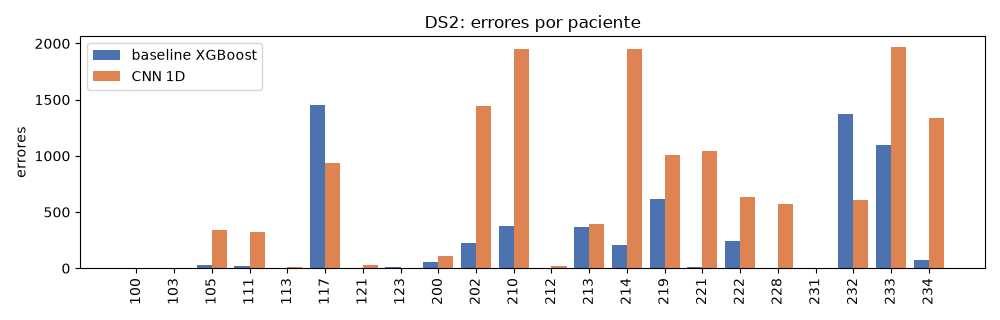

In [8]:
err = pd.DataFrame({NAMES[k]: per_record_metrics(y, p, records)["errores"] for k, p in preds.items()})
err["latidos"] = per_record_metrics(y, preds["cnn"], records)["latidos"]
display(err.sort_values(NAMES["baseline_xgb"], ascending=False).head(6))
Image(str(FIG_DIR / "ds2_errors_by_record.png"))

In [9]:
por_ritmo = riesgos["por_ritmo"]
pd.DataFrame({rh: {f"{NAMES[k]} · {met}": v[k][met] for k in preds for met in ["N_Se", "S_Se", "V_Se"]}
              | {"latidos": v["latidos"]} for rh, v in por_ritmo.items()}).T

,Baseline XGBoost (primario) · N_Se,Baseline XGBoost (primario) · S_Se,Baseline XGBoost (primario) · V_Se,CNN 1D (comparación) · N_Se,CNN 1D (comparación) · S_Se,CNN 1D (comparación) · V_Se,latidos
(N,0.915,0.720,0.962,0.766,0.615,0.963,36159.0
(AFIB,0.854,0.222,0.965,0.347,0.296,0.960,7872.0
(B,0.998,NaN,0.975,0.936,NaN,0.969,1915.0
(SBR,1.000,0.004,NaN,0.997,0.559,NaN,1778.0


**Conclusiones:**

- **El error más frecuente del baseline son falsos F: 2 945 latidos N marcados como fusión**,
  concentrados en dos pacientes (117 con 1 454 y 233 con 1 073) y casi todos en ritmo sinusal
  normal. La clase F funciona como un cajón donde caen los latidos que no encajan: su +P es 0.017.
- **El segundo error son 1 177 latidos S leídos como N**, y 1 082 de ellos son del registro 232.
  Dicho de otra forma: **dos pacientes explican la mitad de los errores del modelo primario.**
- **En fibrilación auricular el baseline aguanta mejor de lo esperado** (Se de N 0.854 en 7 872
  latidos), pero su Se de S cae a 0.222: con RR irregular, distinguir un latido prematuro es
  mucho más difícil. Es el mismo modo de falla que vimos en el 201 de DS1.
- **La CNN se desarma en DS2 por falsas alarmas:** 7 739 falsos F y 2 782 falsos V. Su problema de
  la Fase 4 no solo no desapareció, sino que empeoró con pacientes nuevos.

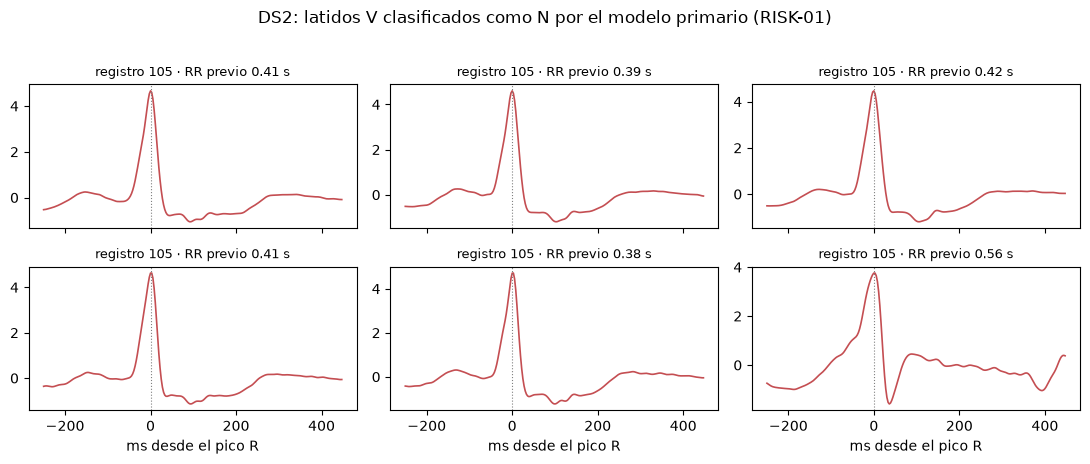

In [10]:
Image(str(FIG_DIR / "ds2_error_examples.png"))

Los 58 latidos V que el modelo primario leyó como N son el error más grave (RISK-01). Se
concentran en el registro 210 (22) y el 213 (14), y varios tienen RR previo largo: sin el indicio
del latido prematuro, la decisión queda solo en la morfología.

## 5. Análisis posterior: agrupar F con V

In [11]:
# Post hoc: no cambia ningún modelo, solo agrupa las etiquetas al evaluar.
tres = {}
for k, p in preds.items():
    y3 = np.where(y == "F", "V", y)
    p3 = np.where(p == "F", "V", p)
    m = per_class_metrics(y3, p3, classes=["N", "S", "V"])
    tres[NAMES[k]] = {"macro_f1_3clases": m["F1"].mean(), **{f"{c}_{x}": m.loc[c, x]
                      for c in ["N", "S", "V"] for x in ["Se", "+P"]}}
pd.DataFrame(tres).T.round(3)

,macro_f1_3clases,N_Se,N_+P,S_Se,S_+P,V_Se,V_+P
Baseline XGBoost (primario),0.578,0.905,0.962,0.155,0.221,0.889,0.476
CNN 1D (comparación),0.573,0.697,0.973,0.558,0.619,0.884,0.195


**Conclusión: agrupar F con V no rescata al modelo, y eso es informativo.**

Contar F junto con V es habitual (un latido de fusión *es* en parte ventricular, y AAMI EC57 evalúa
la detección de latidos ventriculares). Al hacerlo, la F1 macro del baseline sube de 0.512 a
**0.578**, pero ese salto viene sobre todo de **sacar del promedio una clase con F1 0.03**, no de
una mejora real: la Se de V baja a 0.889 y **su +P cae de 0.852 a 0.476**, porque los 3 049 falsos
F pasan a contarse como falsos V.

Dicho de otra forma: **el problema de F no es de definición de la tarea, son falsas alarmas de
verdad.** Con este agrupamiento, uno de cada dos latidos marcados como ventriculares sería falso.
Es un análisis **posterior**, no la métrica principal.

## 6. Conclusiones de la Fase 5

**Resultado final en DS2 (22 pacientes nunca vistos), modelo primario XGBoost:**

| Clase | Se | +P | F1 |
|---|---|---|---|
| N | 0.905 | 0.962 | 0.933 |
| S | 0.155 | 0.221 | 0.182 |
| V | 0.964 | 0.852 | 0.905 |
| F | 0.137 | 0.017 | 0.030 |
| **F1 macro** | | | **0.512** |

Exactitud 0.876, contra 0.890 de predecir siempre N.

**Lo que salió bien**

1. La evaluación inter-paciente **no fue optimista**: la F1 macro de DS2 (0.512) quedó cerca de la
   de validación (0.493). Todo el trabajo de separar pacientes desde el día uno sirvió.
2. **V, la clase clínicamente más importante, funciona:** Se 0.964 y +P 0.852, con solo 58 latidos
   ventriculares leídos como normales de 3 219.
3. El bloqueo de rama izquierda, que en DS1 era el peor modo de falla del baseline, **no se repitió**
   en DS2 (98.9 % y 90.2 % correctos).

**Lo que salió mal, y por qué**

1. **S casi no se detecta (Se 0.155)** y el motivo es un solo paciente: el 232 aporta el 75 % de los
   S de DS2 y el modelo, que usa RR absolutos, ve sus latidos prematuros como normales.
2. **F es inservible (+P 0.017).** Con un solo paciente con F en entrenamiento, no hay nada que
   aprender; el modelo usa la clase como cajón de descarte.
3. **La CNN generaliza peor** (F1 macro 0.49 con exactitud 0.704): demasiadas falsas alarmas.

**Qué haría en una versión 2** (a validar de nuevo en DS1, sin volver a mirar DS2)

1. **Usar solo cocientes de RR**, o normalizar el RR por la mediana del registro. La evidencia del
   232 es clara y en validación la diferencia era nula.
2. **Reportar la clase F junto con V** (sección 5), o declararla fuera del alcance en el uso
   previsto.
3. **Umbral ajustable para F**, con el objetivo de subir su +P.
4. Validación externa con otra base (INCART) para no seguir midiendo en 22 pacientes.

Todo esto va documentado en `docs/model_card.md` y `docs/risk_analysis.md` en la Fase 7.